In [2]:
!pip install -r /content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 3.9 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.3/185.3 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 9.0

In [3]:
from spatialdata_io import xenium
import spatialdata as sd
import scanpy as sc

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:75: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


## Load the Xenium output to a SpatialData object

**FFPE Human Prostate Adenocarcinoma with 5K Human Pan Tissue and Pathways Panel**

https://www.10xgenomics.com/datasets/xenium-prime-ffpe-human-prostate

In [ ]:
xenium_path = "/media/augusta/Xenium5K"
sdata = xenium(xenium_path)

In [ ]:
# Save the spatialdata object
sdata.write('datasets/Xenium5K_human_prostate.zarr')

INFO     The Zarr backing store has been changed from None the new file path: data/Xenium5K_human_prostate.zarr    


In [4]:
sdata = sd.read_zarr("/content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate.zarr")

/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/usr/local/lib/python3.12/dist-packages/zarr/creation.py:610: Use

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Your image has 4 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 


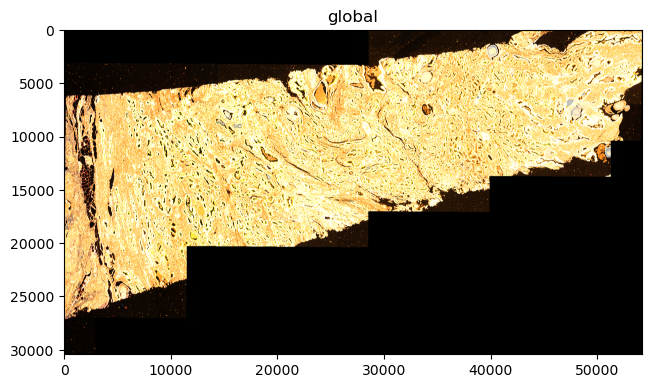

In [22]:
import spatialdata_plot
sdata.pl.render_images().pl.show()

In [5]:
sdata

SpatialData object, with associated Zarr store: /content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 30420, 54160), (4, 15210, 27080), (4, 7605, 13540), (4, 3802, 6770), (4, 1901, 3385)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (30420, 54160), (15210, 27080), (7605, 13540), (3802, 6770), (1901, 3385)
│     └── 'nucleus_labels': DataTree[yx] (30420, 54160), (15210, 27080), (7605, 13540), (3802, 6770), (1901, 3385)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (193000, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (193000, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (184853, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (193000, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_l

In [6]:
adata = sdata.table
adata

/tmp/ipython-input-1089043534.py:1: DeprecationWarning: Table accessor will be deprecated with SpatialData version 0.1, use sdata.tables instead.
  adata = sdata.table


AnnData object with n_obs × n_vars = 193000 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

### Add spatial coordinates to adata

In [8]:
import pandas as pd

# Convert obsm["spatial"] (Nx2 numpy array) to a DataFrame
coords_df = pd.DataFrame(
    adata.obsm["spatial"], 
    columns=["x", "y"], 
    index=adata.obs_names
)

# Add them to adata.obs
adata.obs["x"] = coords_df["x"]
adata.obs["y"] = coords_df["y"]

# Verify
adata.obs[["x", "y"]].head()

,x,y
0,170.855087,2017.241211
1,141.605698,2481.442139
2,198.382446,2414.510010
3,129.322784,2834.657227
4,649.650635,2995.655762


### Subsample the dataset

In [9]:
import numpy as np
import scanpy as sc

# Set random seed for reproducibility (optional)
np.random.seed(42)

# Determine how many cells to keep (5%)
n_cells = int(adata.n_obs * 0.05)

# Randomly choose indices
selected_idx = np.random.choice(adata.n_obs, n_cells, replace=False)

# Subset the AnnData object
adata_subset = adata[selected_idx, :].copy()

In [10]:
adata_fullsize = adata.copy()
adata = adata_subset.copy()

### Cell type annotation of the data

In [11]:
# --- Basic preprocessing ---
adata.layers['raw'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [12]:
# --- Dimensionality reduction ---
sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)

/tmp/ipython-input-729811813.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')


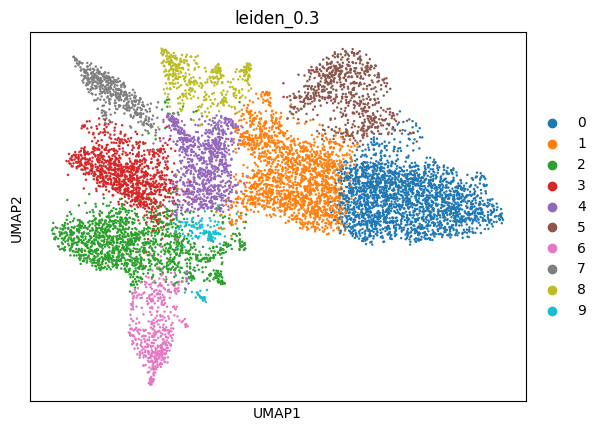

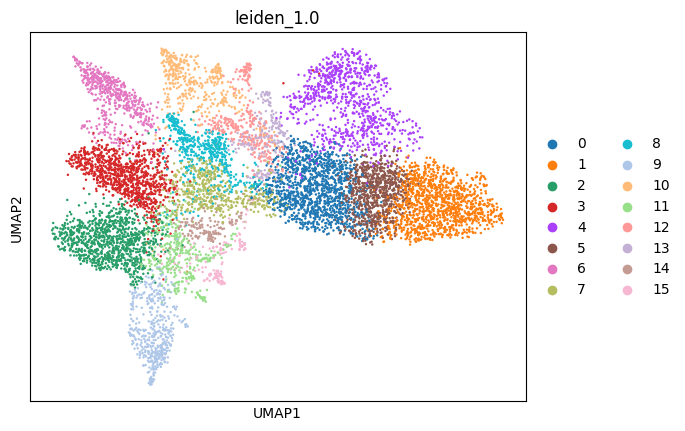

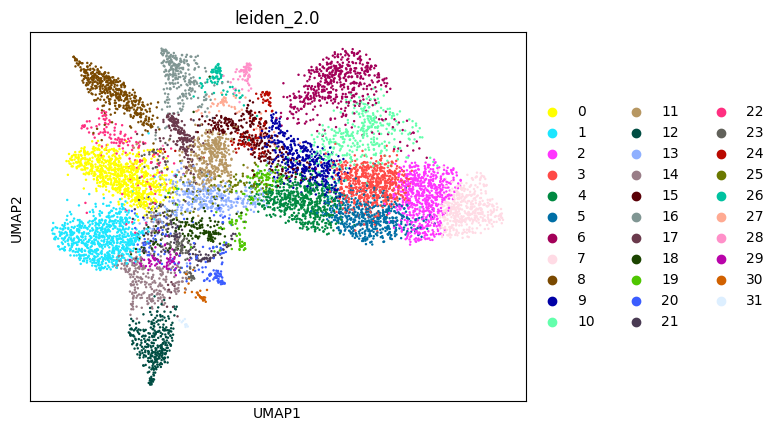

In [13]:
# --- Clustering ---
resolutions = [0.3, 1.0, 2.0]

for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
    # --- Plot clusters ---
    sc.pl.umap(adata, color=f'leiden_{res}')

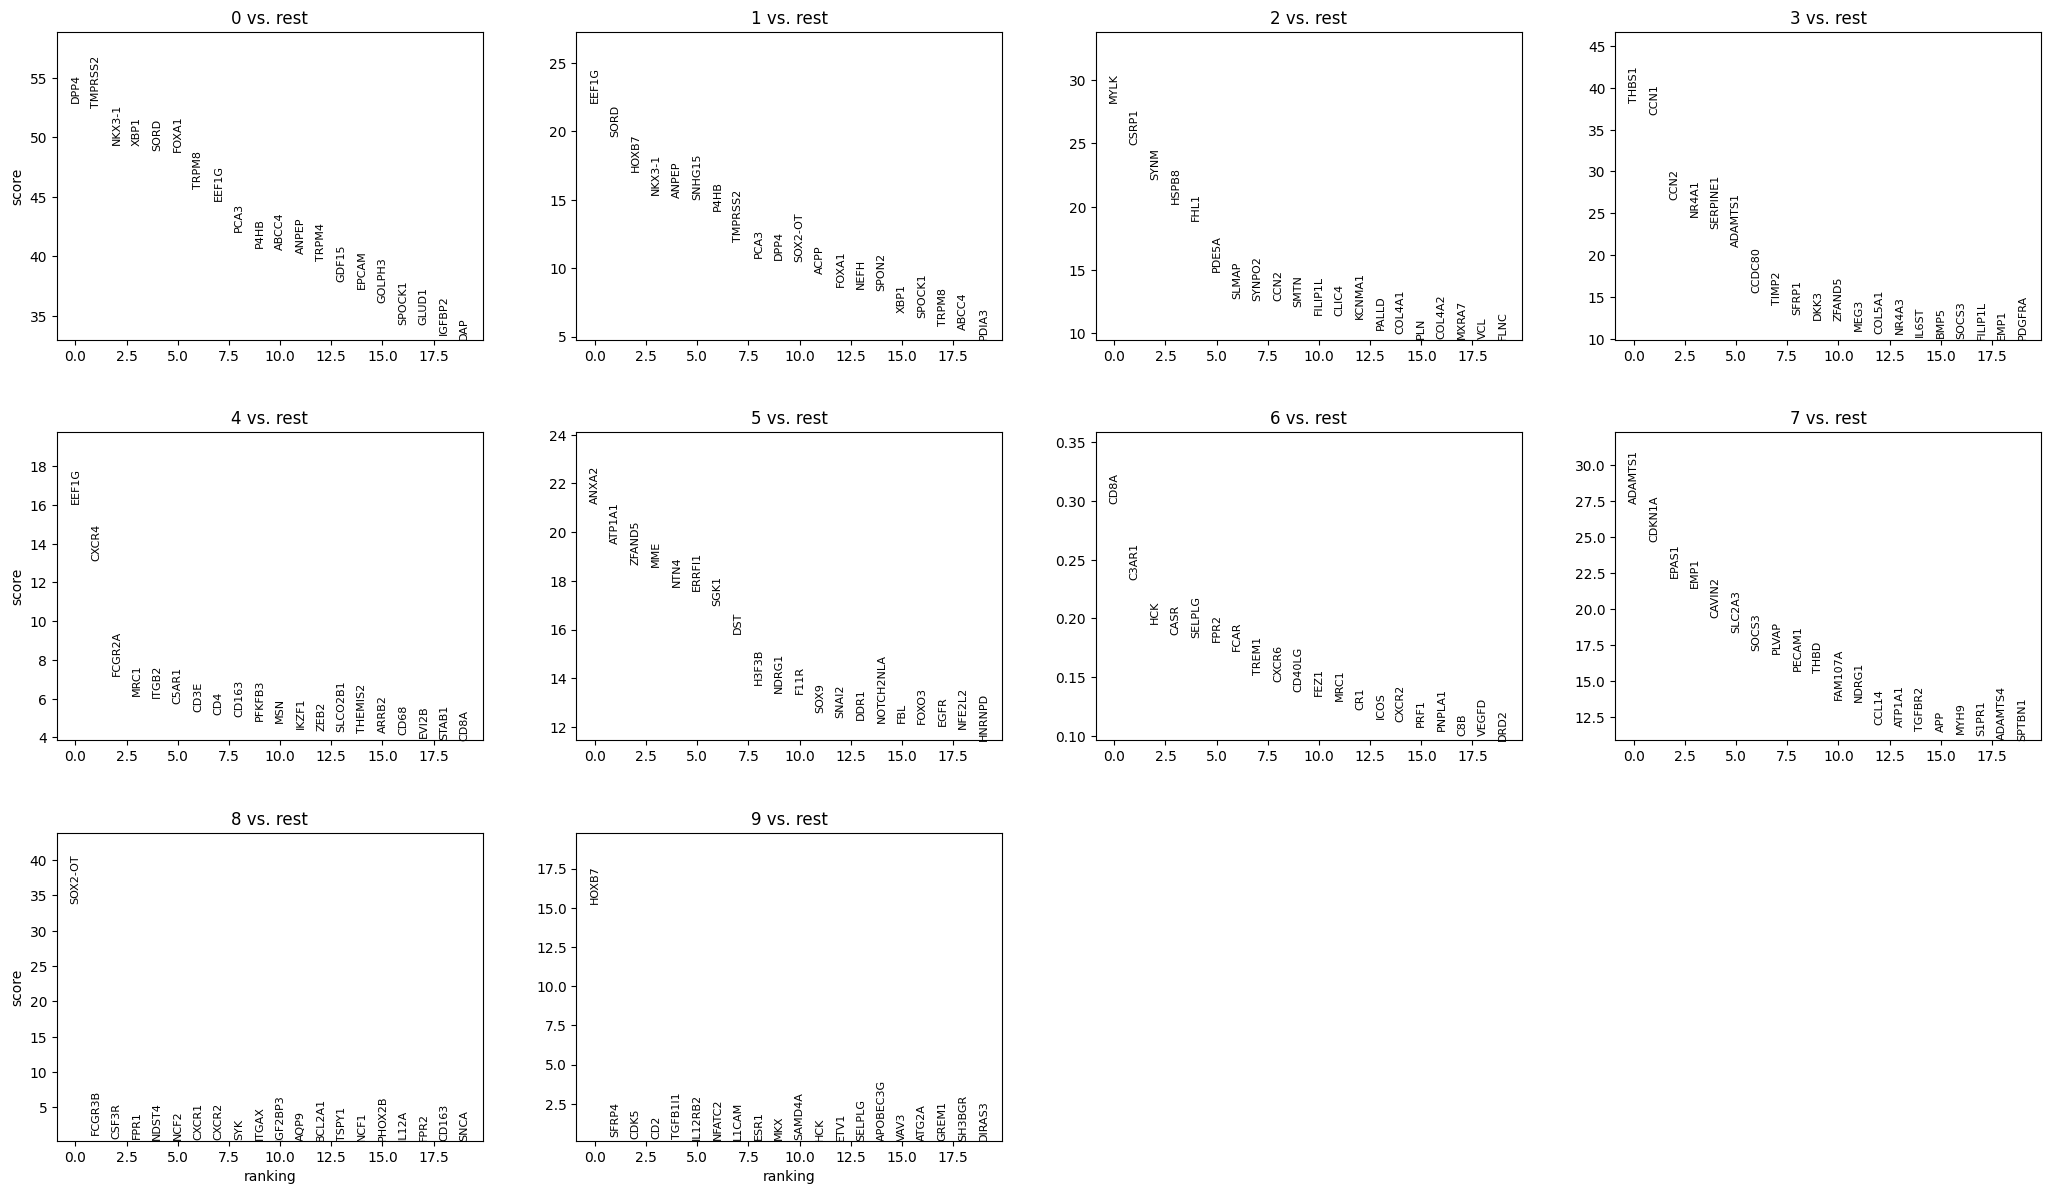

In [14]:
sc.tl.rank_genes_groups(adata, groupby='leiden_0.3', method='wilcoxon')

# Show the top DEGs per cluster
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [15]:
degs_dict = {
    cluster: sc.get.rank_genes_groups_df(adata, group=cluster)
              .sort_values('logfoldchanges', ascending=False)['names']
              .head(10)
              .tolist()
    for cluster in adata.obs['leiden_0.3'].cat.categories
}
degs_dict

{'0': ['SLC17A6',
  'F2',
  'PCK1',
  'APOBEC3B',
  'DPP4',
  'TMPRSS2',
  'TRPM8',
  'NKX3-1',
  'SORD',
  'FOXA1'],
 '1': ['FCRL4',
  'HOXC11',
  'MYH1',
  'MAGEC1',
  'OCM2',
  'CRNN',
  'MAB21L2',
  'SRY',
  'CCKAR',
  'CHST8'],
 '2': ['CMTM5',
  'MAT1A',
  'FLNC',
  'SYNM',
  'MYLK',
  'FHL1',
  'HSPB8',
  'WFDC1',
  'SYNPO2',
  'PLN'],
 '3': ['THBS1',
  'CCN1',
  'SERPINE1',
  'PDGFRA',
  'CCN2',
  'CCDC80',
  'SCN7A',
  'HS6ST2',
  'BMP5',
  'HSD11B1'],
 '4': ['CXCR4',
  'HAVCR2',
  'MS4A2',
  'CD163',
  'VSIG4',
  'CLEC12A',
  'F13A1',
  'EVI2B',
  'SLAMF6',
  'IKZF1'],
 '5': ['LAMB3',
  'TP63',
  'COL17A1',
  'GABRP',
  'CPA6',
  'FAT2',
  'FLRT3',
  'CLDN1',
  'NTN4',
  'MME'],
 '6': ['AQP8',
  'TNR',
  'CASR',
  'SSX1',
  'DPF3',
  'DAOA',
  'CARD9',
  'PNPLA1',
  'LMO1',
  'PRF1'],
 '7': ['PLVAP',
  'TEK',
  'SELP',
  'CDH5',
  'ADGRL4',
  'MMRN2',
  'CLEC14A',
  'CCL14',
  'S1PR1',
  'TIE1'],
 '8': ['SOX2-OT',
  'GLRA2',
  'HAMP',
  'PHOX2B',
  'OBP2A',
  'DYDC1',
  'CXCR2

In [16]:
cell_type_map = {
    "0": "Luminal epithelial / tumor",
    "1": "B cells (atypical/GC-like)",
    "2": "Myofibroblast / smooth muscle-like",
    "3": "CAF (PDGFRA+)",
    "4": "Myeloid (TAM/mono ± mast)",
    "5": "Basal epithelial",
    "6": "Cytotoxic lymphocytes (NK/T)",
    "7": "Endothelial",
    "8": "Neutrophils",
    "9": "NK / activated T (mixed)"
}

adata.obs["cell_type"] = (
    adata.obs["leiden_0.3"].map(cell_type_map).astype("category")
)

status_map = {
    "0": "tumor",   # Luminal epithelial / tumor
    "1": "normal",  # B cells
    "2": "normal",  # Myofibroblast / smooth muscle-like
    "3": "normal",  # CAF (PDGFRA+)
    "4": "normal",  # Myeloid (TAM/mono ± mast)
    "5": "tumor",   # Basal epithelial (often tumor-adjacent/epithelial; mark as tumor per your schema)
    "6": "normal",  # Cytotoxic lymphocytes (NK/T)
    "7": "normal",  # Endothelial
    "8": "normal",  # Neutrophils
    "9": "normal"   # NK / activated T (mixed)
}

adata.obs["status"] = (
    adata.obs["leiden_0.3"].map(status_map).astype("category")
)

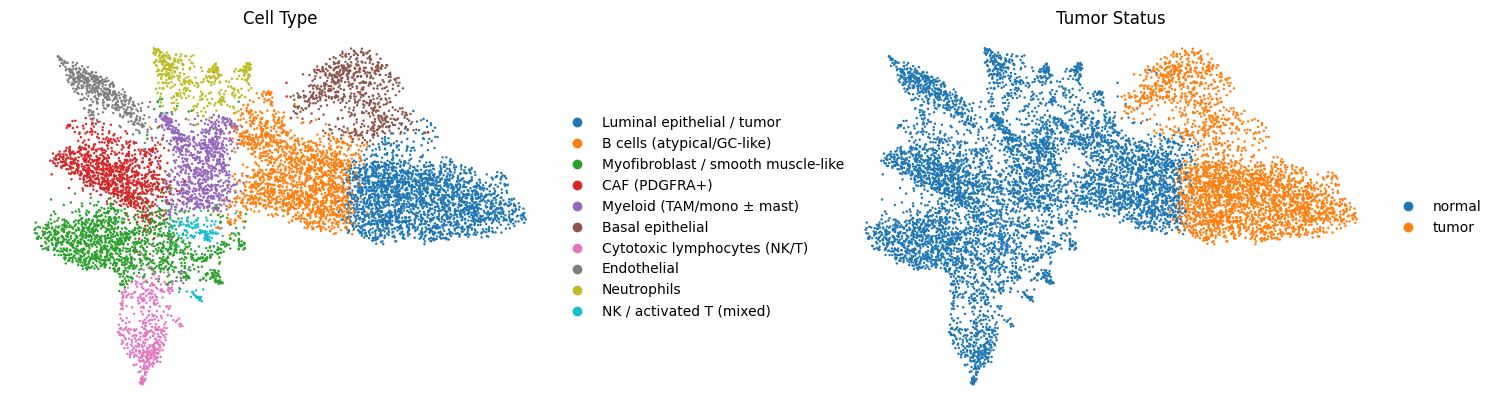

In [17]:
import scanpy as sc
import matplotlib.pyplot as plt

# UMAP of cell type and status
sc.pl.umap(
    adata,
    color=["cell_type", "status"],
    ncols=2,
    wspace=0.4,
    frameon=False,
    title=["Cell Type", "Tumor Status"]
)

In [19]:
adata

AnnData object with n_obs × n_vars = 9650 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'x', 'y', 'leiden_0.3', 'leiden_1.0', 'leiden_2.0', 'cell_type', 'status'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'rank_genes_groups', 'cell_type_colors', 'status_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'distances', 'connectivities'

### Add genomic positions of genes

In [22]:
import infercnvpy as cnv
cnv.io.genomic_position_from_biomart(adata, adata_gene_id="gene_ids" ,species="hsapiens")

## Save the adata

In [ ]:
adata.write('/content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate_subset.h5ad')

In [5]:
import scanpy as sc
adata = sc.read_h5ad('/content/drive/MyDrive/Courses/DDLS_course/Final_Project/clearCNV/datasets/Xenium5K_human_prostate_subset.h5ad')

In [6]:
adata


AnnData object with n_obs × n_vars = 9650 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'x', 'y', 'leiden_0.3', 'leiden_1.0', 'leiden_2.0', 'cell_type', 'status'
    var: 'gene_ids', 'feature_types', 'genome', 'ensembl_gene_id', 'start', 'end', 'chromosome'
    uns: 'cell_type_colors', 'leiden_0.3', 'leiden_0.3_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatialdata_attrs', 'status_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'connectivities', 'distances'

In [7]:
adata.X = adata.layers['raw'].copy()

In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

,total_counts,n_genes_by_counts
count,9650.000000,9650.000000
mean,204.330780,156.707254
std,201.033615,132.511925
min,0.000000,0.000000
25%,62.000000,56.000000
50%,142.000000,120.000000
75%,281.000000,222.000000
max,2074.000000,966.000000


In [15]:
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)
print("Mean counts per cell:", adata.obs['total_counts'].mean())
print("Median counts per cell:", adata.obs['total_counts'].median())
print("Mean genes per cell:", adata.obs['n_genes_by_counts'].mean())


Cells: 9650
Genes: 5006
Mean counts per cell: 204.33078
Median counts per cell: 142.0
Mean genes per cell: 156.70725388601036


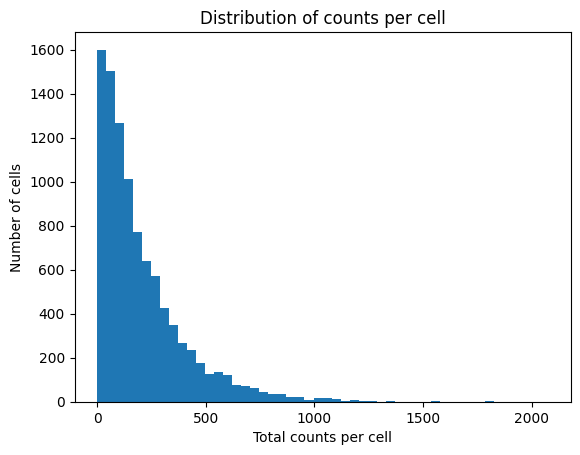

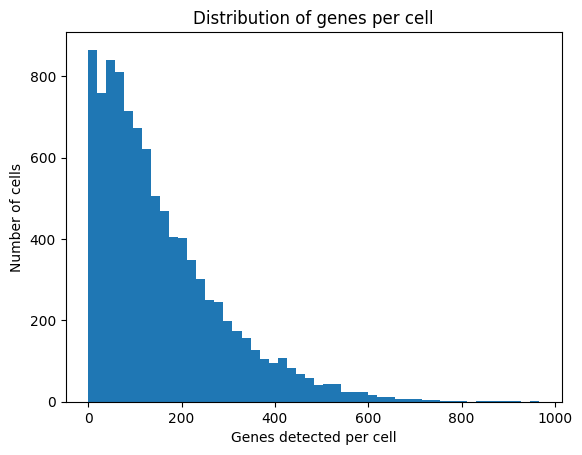

In [16]:
import matplotlib.pyplot as plt

# Histogram of total counts per cell
plt.hist(adata.obs['total_counts'], bins=50)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of counts per cell")
plt.show()

# Histogram of genes per cell
plt.hist(adata.obs['n_genes_by_counts'], bins=50)
plt.xlabel("Genes detected per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of genes per cell")
plt.show()
